In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import imageio
import cartopy.crs as ccrs
import rioxarray
import cartopy.feature as feature
import geopandas as gpd
from shapely.geometry import mapping
import pandas as pd
import matplotlib.patches as patches
import numpy as np

from matplotlib import cm
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm as cmo
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [32]:
# get the grid cell area
def get_grid_info(ds):
    """Return grid cell area and lenght of the sides."""
    dg = 111089.56  # [m] length of 1 degree latitude
    erad = 6.371e6  # [m] Earth radius

    latitude = ds.latitude.values
    longitude = ds.longitude.values
    dx_deg = np.abs(longitude[1] - longitude[0])  # [degrees]
    dy_deg = np.abs(latitude[1] - latitude[0])  # [degrees]

    # Calculate area TODO check this calculation!
    lat_n = np.minimum(90.0, latitude + 0.5 * dx_deg)
    lat_s = np.maximum(-90.0, latitude - 0.5 * dx_deg)

    a = (
        np.pi
        / 180.0
        * erad**2
        * dx_deg
        * abs(np.sin(lat_s * np.pi / 180.0) - np.sin(lat_n * np.pi / 180.0))
    )

    # Calculate faces
    dy = dy_deg * dg  # [m] grid spacing in meridional direction
    dx_n_gridcell = dx_deg * dg * np.cos((latitude + dx_deg / 2) * np.pi / 180)
    dx_s_gridcell = dx_deg * dg * np.cos((latitude - dx_deg / 2) * np.pi / 180)
    dx = 0.5 * (dx_n_gridcell + dx_s_gridcell)  # [m] grid spacing in zonal direction
    return a, dy, dx, latitude, longitude

In [33]:
# ----- Límites del dominio completo -----
lat_min, lat_max = -20, 25
lon_min, lon_max = -80, -15

# Resolución de la grilla (0.25° es la de ERA5)
res = 0.25

# Crear coordenadas
latitudes = np.arange(lat_max, lat_min - res, -res)  # de norte a sur
longitudes = np.arange(lon_min, lon_max + res, res)

# ----- Crear grilla vacía -----
mask = np.zeros((len(latitudes), len(longitudes)))

# ----- Región de interés -----
tagging_region = [-73.9, 4.30, -73.4, 4.8]  # [lon_min, lat_min, lon_max, lat_max]
lon_min_r, lat_min_r, lon_max_r, lat_max_r = tagging_region

# Encontrar índices donde la condición se cumple
lat_cond = (latitudes <= lat_max_r) & (latitudes >= lat_min_r)
lon_cond = (longitudes >= lon_min_r) & (longitudes <= lon_max_r)

# Asignar 1 en la región
mask[np.ix_(lat_cond, lon_cond)] = 1

# ----- Crear DataArray -----
region = xr.DataArray(
    mask,
    coords={"latitude": latitudes, "longitude": longitudes},
    dims=["latitude", "longitude"],
    name="tagging_region",
    attrs={
        "description": "Máscara de la región Chingaza dentro del dominio tropical.",
        "tagging_region": str(tagging_region),
        "domain": str([lon_min, lat_min, lon_max, lat_max]),
    },
)

a_gridcell, dy, dx, latitude, longitude = get_grid_info(region)
a_gridcell_2D = np.broadcast_to(np.transpose([a_gridcell]), (len(latitude), len(longitude)))


In [12]:
ruta_carpeta = "output_data"
datasets = []

# Validar que la carpeta exista y ordenar la lista de archivos para tener orden cronológico
if os.path.exists(ruta_carpeta):
    archivos = sorted([f for f in os.listdir(ruta_carpeta) if f.endswith(".nc")])
    
    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_carpeta, archivo)
        # Solo intentar abrir si el archivo no está vacío (> 0 bytes)
        if os.path.getsize(ruta_archivo) > 0:
            try:
                ds = xr.open_dataset(ruta_archivo, engine="netcdf4")
                datasets.append(ds)
            except Exception as e:
                print(f"Advertencia: No se pudo leer {archivo}. Error: {e}")
        else:
            print(f"Advertencia: El archivo {archivo} está vacío y será omitido.")

if datasets:
    # Concatenar y asegurar el orden por la dimensión de tiempo
    output_combinado = xr.concat(datasets, dim="time").sortby("time")
    output_combinado.to_netcdf("output_combinado.nc")
    print("Archivos combinados exitosamente en 'output_combinado.nc'.")
else:
    print(f"No se encontraron archivos .nc válidos o no vacíos en '{ruta_carpeta}'.")

Archivos combinados exitosamente en 'output_combinado.nc'.


In [ ]:
ruta_carpeta = "preprocessed_data"
datasets = []

if os.path.exists(ruta_carpeta):
    archivos = sorted([f for f in os.listdir(ruta_carpeta) if f.endswith(".nc")])
    
    for archivo in archivos:
        ds = xr.open_dataset(os.path.join(ruta_carpeta, archivo))
        datasets.append(ds)

if datasets:
    preprocess_combinado = xr.concat(datasets, dim="time").sortby("time")
    preprocess_combinado.to_netcdf("preprocess_combinado.nc")
    print("Archivos combinados exitosamente en 'preprocess_combinado.nc'.")
else:
    print(f"No se encontraron archivos .nc válidos en '{ruta_carpeta}'.")

Archivos combinados exitosamente en 'preprocess_combinado.nc'.


In [28]:
# 0. EXTRAER VARIABLES NECESARIAS
from scipy.ndimage import gaussian_filter

print("Extrayendo y preparando variables...")

# Asignamos los datasets combinados obtenidos en pasos anteriores
output = output_combinado
preprocess = preprocess_combinado

# --- De output (output) ---
tagged_precip = output.tagged_precip.sum('time')

e_track_raw = output.e_track.sum('time')
e_track = e_track_raw # Usamos el mismo sum('time')

losses = output.losses.sum('time')

# --- De preprocess (input) ---
# Asume que tiene las variables de flujo fx y fy, promediándolas en el tiempo
fx_interest = (preprocess.fx_upper + preprocess.fx_lower).mean("time")
fy_interest = (preprocess.fy_upper + preprocess.fy_lower).mean("time")
f_hypot = np.hypot(fx_interest, fy_interest)

# Coordenadas
longitude = output.longitude.values
latitude = output.latitude.values

# --- MIP Areas y cálculos de contorno ---
e_track_values = gaussian_filter(e_track_raw.values, sigma=1.5)
flat_data = e_track_values.flatten()
sorted_indices = np.argsort(flat_data)[::-1]
sorted_contributions = flat_data[sorted_indices]

cumulative_contribution = np.cumsum(sorted_contributions) / np.sum(flat_data)
thresholds = [0.2, 0.4, 0.6, 0.8]
mip_areas = {}

for threshold in thresholds:
    num_cells = np.searchsorted(cumulative_contribution, threshold)
    mip_areas[threshold] = sorted_indices[:num_cells]

# Definimos variables extras con alias para ser usadas luego
tagged_precip_mm = tagged_precip
e_track_region = e_track

print("¡Variables preparadas correctamente!")

Extrayendo y preparando variables...
¡Variables preparadas correctamente!


In [34]:
# 1. ESTADÍSTICOS Y TOTALES SIMPLIFICADOS
print("Calculando estadísticos de humedad...")

# Asegúrate de que las variables 'a_gridcell_2D' y 'region' estén definidas
# en celdas anteriores antes de ejecutar esta parte.

# Convertir a metros cúbicos
totales = {
    'tagged_precip_m3': np.sum(tagged_precip.to_numpy() / 1000 * a_gridcell_2D),
    'e_track_m3': np.sum(e_track.to_numpy() / 1000 * a_gridcell_2D),
    'e_track_region_m3': np.sum((e_track.to_numpy() / 1000 * a_gridcell_2D)[region == 1]),
    'internal_losses_m3': np.sum((losses.to_numpy() / 1000 * a_gridcell_2D)[1:-1, 1:-1]),
}

losses_m3 = losses.to_numpy() / 1000 * a_gridcell_2D
totales['boundary_transport'] = np.sum(losses_m3[0,:]) + np.sum(losses_m3[-1,:]) + np.sum(losses_m3[1:-1,0]) + np.sum(losses_m3[1:-1,-1])

# Porcentajes
porcentajes = {
    'retrieved_water': (totales['e_track_m3'] + totales['internal_losses_m3'] + totales['boundary_transport']) / totales['tagged_precip_m3'] * 100,
    'attributed_to_source': totales['e_track_m3'] / totales['tagged_precip_m3'] * 100,
    'boundary_transport_pct': totales['boundary_transport'] / totales['tagged_precip_m3'] * 100,
    'regional_recycling': totales['e_track_region_m3'] / totales['tagged_precip_m3'] * 100
}

for k, v in totales.items(): 
    print(f"{k} = {v:.2e} m3")
print("-" * 30)
for k, v in porcentajes.items(): 
    print(f"{k} = {v:.2f} %")

Calculando estadísticos de humedad...
tagged_precip_m3 = 8.09e+08 m3
e_track_m3 = 3.95e+08 m3
e_track_region_m3 = 1.11e+07 m3
internal_losses_m3 = 0.00e+00 m3
boundary_transport = 1.39e+08 m3
------------------------------
retrieved_water = 66.04 %
attributed_to_source = 48.82 %
boundary_transport_pct = 17.22 %
regional_recycling = 1.37 %


Generando Figura MIPs...


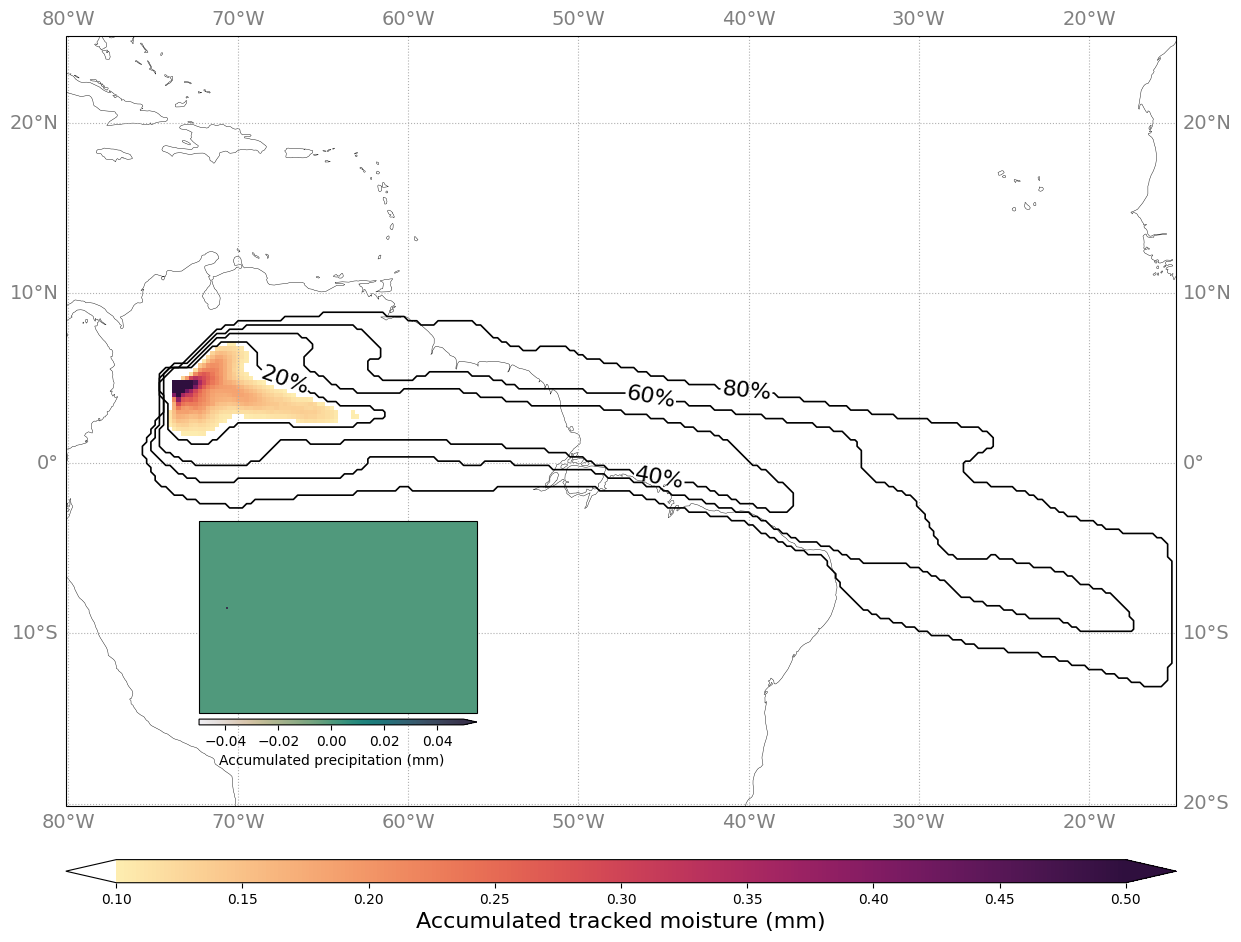

In [37]:
# 2. FIGURA DE MIPS + MOISTURE (Sin Basins)
from scipy.ndimage import binary_fill_holes, binary_closing
from IPython.display import clear_output

# Nota: Asegúrate de tener definido 'chingaza' (feature para el mapa)
# y 'chingaza_gdf' antes de correr esto.

print("Generando Figura MIPs...")

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Formato mapa
ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.3)
if 'chingaza' in globals():
    ax.add_feature(chingaza, linewidth=1) # Añadimos solo Chingaza

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle=':')
gl.xlabel_style, gl.ylabel_style = {'size': 14, 'color': 'gray'}, {'size': 14, 'color': 'gray'}

# Moisture Colormap
e_cmap = plt.get_cmap(cmo.matter).copy()
e_cmap.set_extremes(under='white')
im = e_track.plot(ax=ax, cmap=e_cmap, add_colorbar=False, vmin=0.1, vmax=0.5, robust=True)

cax = ax.inset_axes([0, -0.1, 1, 0.03])
cbar = plt.colorbar(im, cax, orientation="horizontal", extend='both')
cbar.set_label("Accumulated tracked moisture (mm)", fontsize=16)

# Inset de precipitación
ax2 = ax.inset_axes([0.12, 0.12, 0.25, 0.25], projection=ccrs.PlateCarree())
im2 = tagged_precip_mm.plot(ax=ax2, cmap=cmo.rain, add_colorbar=False, vmin=0, robust=True, alpha=0.9)
cax2 = ax2.inset_axes([0, -0.06, 1, 0.03])
plt.colorbar(im2, cax2, orientation="horizontal", extend='max').set_label("Accumulated precipitation (mm)")

# Solo Chingaza en el Inset
if 'chingaza' in globals() and 'chingaza_gdf' in globals():
    ax2.add_feature(chingaza, linewidth=1)
    minx, miny, maxx, maxy = chingaza_gdf.total_bounds
    ax2.set_extent([minx+0.02, maxx, miny+0.05, maxy], crs=ccrs.PlateCarree())

# MIP Contours
colors = cm.viridis(np.linspace(0, 1, len(mip_areas)))
for i, (threshold, cells) in enumerate(mip_areas.items()):
    mip_mask = np.zeros_like(flat_data, dtype=bool)
    mip_mask[cells] = True
    mip_mask = binary_closing(binary_fill_holes(mip_mask.reshape(e_track.shape)), structure=np.ones((3, 3)))
    
    contours = ax.contour(
        e_track_raw.longitude.values, e_track_raw.latitude.values, mip_mask,
        levels=[0.5], colors=['black'], linewidths=1.2, transform=ccrs.PlateCarree()
    )
    ax.clabel(contours, fmt={0.5:f"{int(threshold * 100)}%"}, inline=True, fontsize=16, colors=['black'])

plt.savefig("eiffel_new_sin_basins.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# 3. GENERADOR DE GIF (Sin basins)
import os
from PIL import Image

gif_folder = "gif_frames"
os.makedirs(gif_folder, exist_ok=True)
num_days = len(output_combinado.time)
e_cmap = plt.get_cmap(cmo.matter).copy()
e_cmap.set_extremes(under='white')

print(f"Generando {num_days} frames en {gif_folder}")

for t_idx in range(num_days):
    date_str = pd.to_datetime(output_combinado.time[t_idx].values).strftime('%Y-%m-%d')
    e_track_day = output_combinado.e_track.isel(time=t_idx)
    
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
    # Base (Sin cuencas)
    ax.add_feature(feature.COASTLINE, linewidth=0.3)
    if 'chingaza' in globals():
        ax.add_feature(chingaza, linewidth=1)
    
    im = e_track_day.plot(ax=ax, cmap=e_cmap, add_colorbar=False, vmin=0.001, vmax=0.1, robust=True)
    ax.streamplot(longitude, latitude, fx_interest, fy_interest, transform=ccrs.PlateCarree(), 
                  color='indianred', linewidth=f_hypot.values/300, density=0.1)
    
    cax = ax.inset_axes([0, -0.1, 1, 0.03])
    plt.colorbar(im, cax, orientation="horizontal", extend='both').set_label(f"Tracked moisture (mm) - {date_str}")
    
    plt.savefig(os.path.join(gif_folder, f"frame_{t_idx:04d}.png"), bbox_inches="tight", dpi=150)
    plt.close(fig)
    
    if (t_idx + 1) % 10 == 0:
        clear_output(wait=True)
        print(f"Completado {t_idx + 1}/{num_days} frames...")

clear_output(wait=True)
print("¡Todos los frames generados! Procediendo a compilar el GIF...")

# Compilar los frames en un archivo GIF
output_path = "output_animation.gif"
frames = [os.path.join(gif_folder, f) for f in os.listdir(gif_folder) if f.endswith('.png')]
frames.sort()

images = [Image.open(f) for f in frames]

if images:
    images[0].save(
        output_path,
        format="GIF",
        append_images=images[1:],
        save_all=True,
        duration=80,  # duración de cada frame en milisegundos
        loop=0,       # 0 significa loop infinito
        optimize=True
    )
    print(f"✓ GIF guardado exitosamente en {output_path}")
else:
    print("✗ No se encontraron frames para generar el GIF.")

¡Frames para el GIF finalizados! (Procesa las imágenes a GIF usando imageio convert o similar)
